<a href="https://colab.research.google.com/github/rajiv-ranjan/cds-mini-projects/blob/saif/M8_NB_MiniProject_2_EDA_Timeseries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Advanced Certification Program in Computational Data Science
## A program by IISc and TalentSprint
### Mini-Project: Exploratory Data Analysis - Timeseries

## Problem Statement

Perform Exploratory Data Analysis (EDA) of Retail Sales time series data using visualizations and statistical methods.

## Learning Objectives

At the end of the mini-project, you will be able to :

* perform Exploratory data analysis (EDA) of the time series
* perform Time series behaviour analysis in qualitative and quantitative terms
* summarize the findings based on the EDA

## Dataset

The dataset is a French retail company quarterly sales data that has been made available from  Prof. Rob Hyndman's ["Forecasting Methods & Applications"](https://robjhyndman.com/forecasting/) book. There are 24 entries, from 2012-03-31 to 2017-12-31 (Quarterly sales values).

## Introduction

Exploratory data analysis of time series data starts with data visualization.

- Are there consistent patterns?
- Is there a significant trend?
- Is seasonality important?
- Is there evidence of the presence of business cycles?
- Are there any outliers in the data that need to be explained by those with expert knowledge?
- How strong are the relationships among the variables available for analysis?

Various tools have been developed to help with these analyses.

## Grading = 10 Points

In [1]:
#@title Download Dataset
!wget -qq https://cdn.iisc.talentsprint.com/CDS/Datasets/ts_frenchretail.csv

### Importing libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-white')
%matplotlib inline
import scipy
from pandas.plotting import lag_plot
from statsmodels.graphics.tsaplots import month_plot, seasonal_plot, quarter_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import signal
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

### Import the Data

In [3]:
# Read dataset with 'Date' as index
# YOUR CODE HERE
df = pd.read_csv('ts_frenchretail.csv', index_col='Date', parse_dates=True)

print(df.head())

             Sales
Date              
2012-03-31  362000
2012-06-30  385000
2012-09-30  432000
2012-12-31  341000
2013-03-31  382000


## Exploratory Data Analysis

### **Preprocessing** (1 point)

#### Divide the sales by 1000

Sales numbers are in thousands, so divide by 1000 to make it easier to work with numbers

In [4]:
# YOUR CODE HERE
df['Sales'] = df['Sales'] / 1000
print(df)

            Sales
Date             
2012-03-31  362.0
2012-06-30  385.0
2012-09-30  432.0
2012-12-31  341.0
2013-03-31  382.0
2013-06-30  409.0
2013-09-30  498.0
2013-12-31  387.0
2014-03-31  473.0
2014-06-30  513.0
2014-09-30  582.0
2014-12-31  474.0
2015-03-31  544.0
2015-06-30  582.0
2015-09-30  681.0
2015-12-31  557.0
2016-03-31  628.0
2016-06-30  707.0
2016-09-30  773.0
2016-12-31  592.0
2017-03-31  627.0
2017-06-30  725.0
2017-09-30  854.0
2017-12-31  661.0


#### Check for missing values     

In [5]:
# YOUR CODE HERE
missing_values = df.isnull().sum()
print(missing_values)

Sales    0
dtype: int64


### **Visualization**

#### Visualize the time series (2012 to 2017) (1 point)

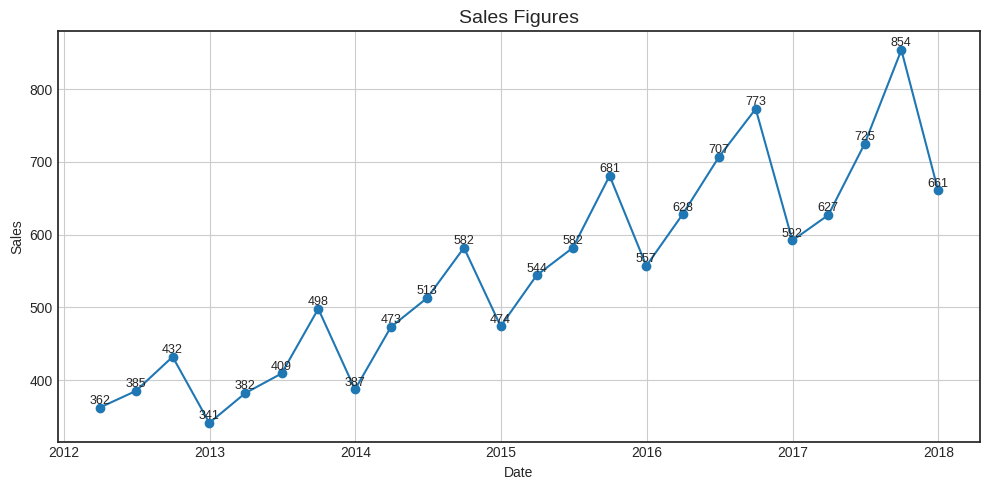

In [6]:
# YOUR CODE HERE
#time series plot
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Sales'], marker='o', linestyle='-')
for x, y in zip(df.index, df['Sales']): #data labels
    plt.text(x, y + 5, f'{y:.0f}', ha='center', fontsize=9)
plt.title('Sales Figures', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Visualize the data year-wise and quarter-wise (2 points)

- Box plot to see distribution of sales in each year
- Create year-wise subplots to visualize the quarterly Sales per year
- Compute Percentage growth each year

Make a report of your observations.

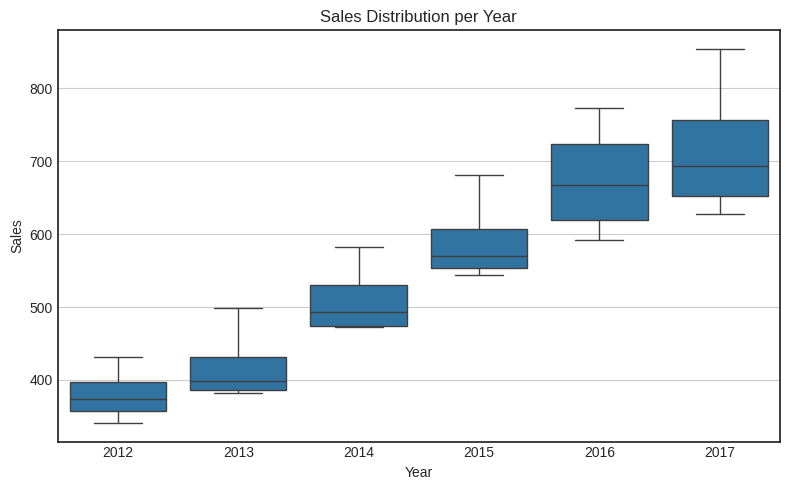

In [7]:
# Box plot to see distribution of sales in each year
# YOUR CODE HERE
df['Year'] = df.index.year
# boxplot chart
plt.figure(figsize=(8, 5))
sns.boxplot(x='Year', y='Sales', data=df)
plt.title('Sales Distribution per Year')
plt.ylabel('Sales')
plt.xlabel('Year')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

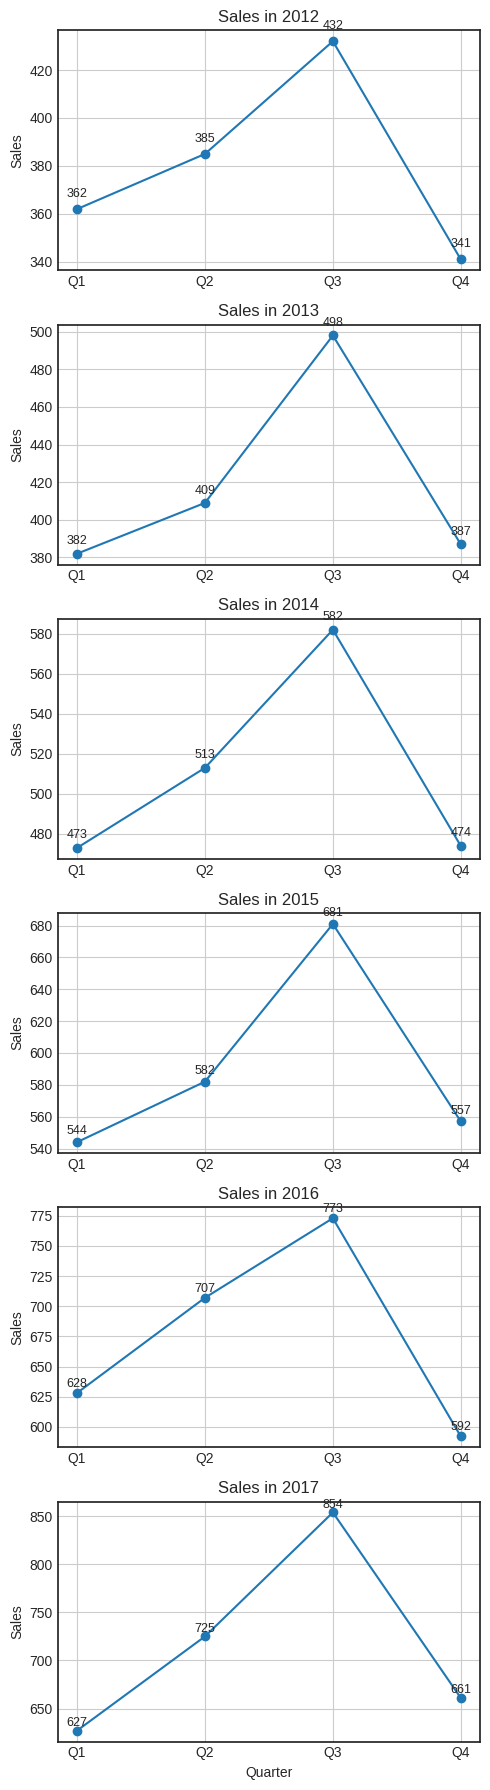

In [8]:
# Create year-wise subplots to visualize the quarterly Sales per year
# YOUR CODE HERE
#df['Year'] = df.index.year
df['Quarter'] = df.index.quarter

years = df['Year'].unique() # Get unique years
n = len(years)

#subplots
fig, axes = plt.subplots(n, 1, figsize=(5, 3 * n))

for i, year in enumerate(years):
    ax = axes[i] if n > 1 else axes
    year_data = df[df['Year'] == year]
    ax.plot(year_data['Quarter'], year_data['Sales'], marker='o', linestyle='-')
    for q, s in zip(year_data['Quarter'], year_data['Sales']):  #labels
        ax.text(q, s + 5, f'{s:.0f}', ha='center', fontsize=9)
    ax.set_title(f'Sales in {year}')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
    ax.set_ylabel('Sales')
    ax.grid(True)

plt.xlabel('Quarter')
plt.tight_layout()
plt.show()

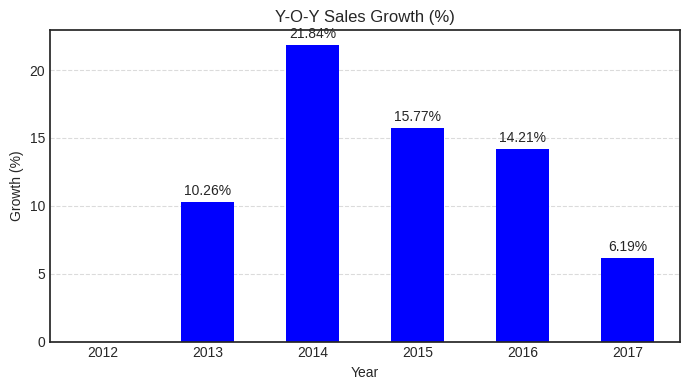

In [9]:
# Percentage growth each year
# YOUR CODE HERE
yearly_sales = df.groupby('Year')['Sales'].sum()
growth = yearly_sales.pct_change() * 100  # percentage growth

# Plot
plt.figure(figsize=(7,4))
growth.plot(kind='bar', color='blue')
plt.title('Y-O-Y Sales Growth (%)')
plt.xlabel('Year')
plt.ylabel('Growth (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for idx, val in enumerate(growth):              #data labels
    if not pd.isna(val):
        plt.text(idx, val + (0.5 if val > 0 else -3), f'{val:.2f}%', ha='center')

plt.tight_layout()
plt.show()

#### Visualize the distribution of the Sales (0.5 point)

While normally distributed data is not a requirement for forecasting and doesn't necessarily improve point forecast accuracy, it can help stablize the variance and narrow the prediction interval.

Report your observations.

Hint: `sns.distplot()`

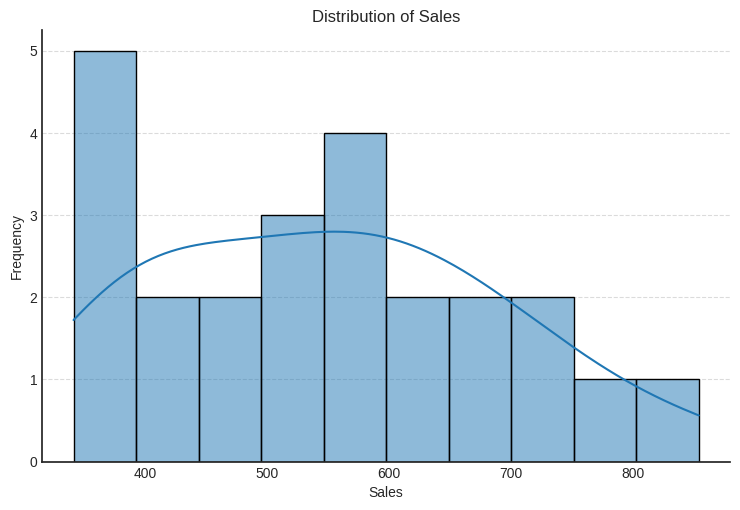

In [10]:
# YOUR CODE HERE
sns.displot(df['Sales'], kde=True, bins=10, aspect=1.5)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Visualize Quarterly trends (1 point)

Create quarterly subplots to visualize the data in each quarter across all years

Hint: statsmodels' `quarter_plot()` method

<Figure size 1000x800 with 0 Axes>

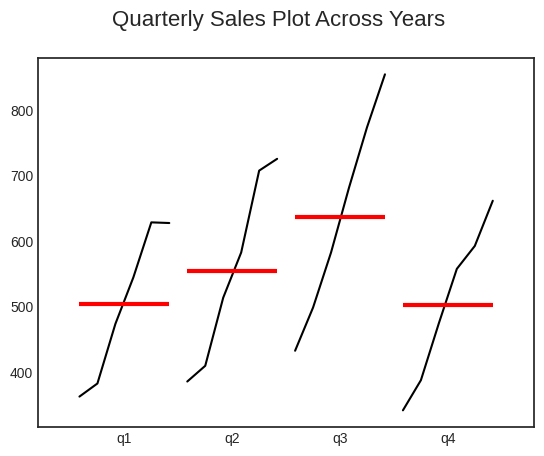

In [11]:
# YOUR CODE HERE
plt.figure(figsize=(10, 8))
quarter_plot(df['Sales'])
plt.suptitle('Quarterly Sales Plot Across Years', fontsize=16)
plt.show()

#### Visualize the distribution of Sales in each year within a single plot (1 point)

- Do the distribution peaks shift to the right from 2012 to 2017? What does this indicate?
- Is there a change in the width of the distributions from 2012 to 2017? What does it signify?

Hint: `sns.distplot(hist=False)`

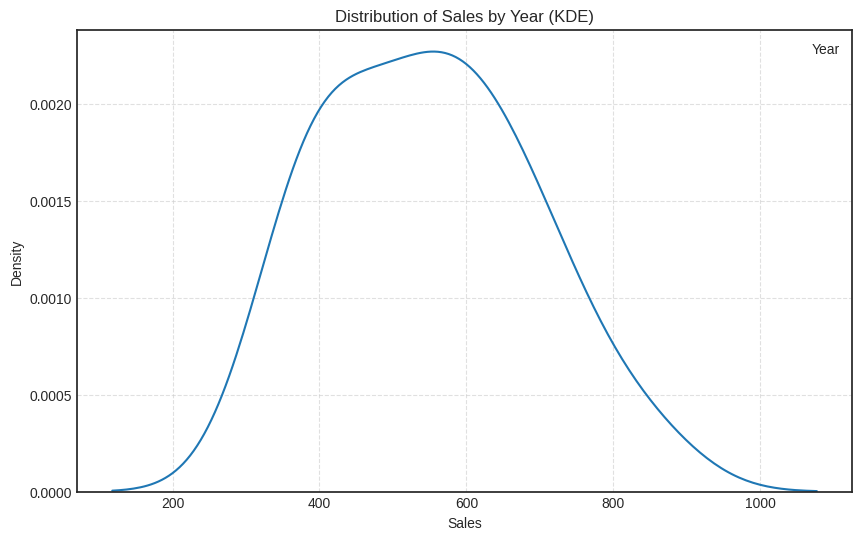

In [12]:
# Distribution plot of each year
# YOUR CODE HERE
plt.figure(figsize=(10,6))
years1 = sorted(df['Year'].unique())
#palette = sns.color_palette("viridis", len(years1))
#sns.distplot(data = df, x='Sales', hue = 'Year', hist=False, kde=True)

#for i, year in enumerate(years1):
    #subset = df[df['Year'] == year]
    #sns.kdeplot(subset['Sales'], bw_adjust=0.5, label=str(year), color=palette[i])
sns.distplot(df['Sales'], hist=False, kde=True)
plt.title('Distribution of Sales by Year (KDE)')
plt.xlabel('Sales')
plt.ylabel('Density')
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Visualize the quarterly sales for each year using a stacked bar plot (1 point)

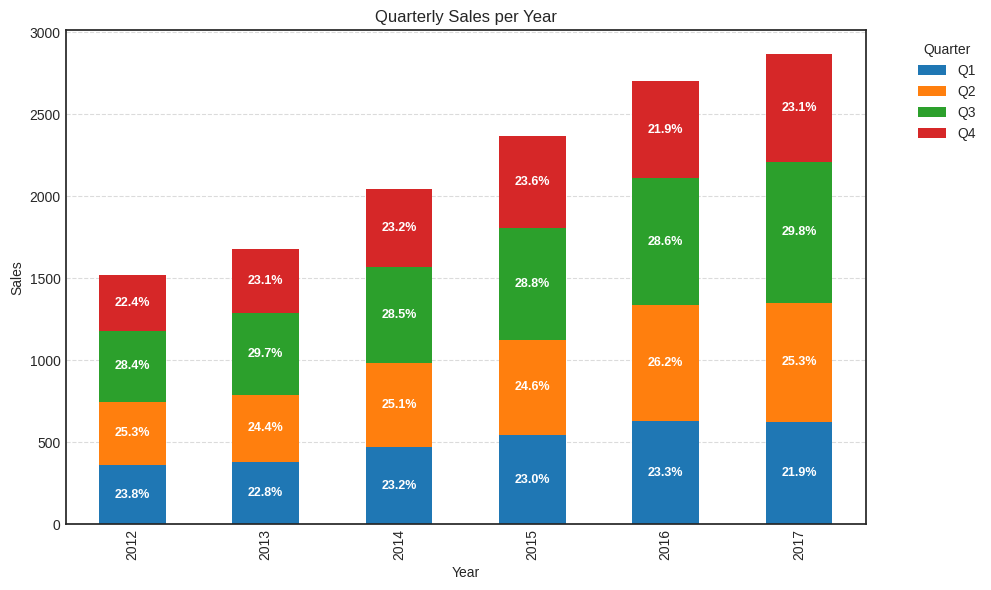

In [13]:
df['Quarter'] = 'Q' + df.index.quarter.astype(str)

pivot_df = df.pivot_table(values='Sales', index='Year', columns='Quarter')
pivot_df = pivot_df[['Q1', 'Q2', 'Q3', 'Q4']]
percent_df = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

# stacked bar plot
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title('Quarterly Sales per Year')
plt.ylabel('Sales')
plt.xlabel('Year')
plt.legend(title='Quarter', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

#percentage labels
for bar_idx, (year, row) in enumerate(pivot_df.iterrows()):
    cumulative_height = 0
    for quarter in ['Q1', 'Q2', 'Q3', 'Q4']:
        sales_value = row.get(quarter, 0)
        percent_value = percent_df.loc[year, quarter]
        if sales_value > 0:
            ax.text(
                bar_idx, cumulative_height + sales_value / 2,
                f'{percent_value:.1f}%', ha='center', va='center',
                color='white', fontsize=9, weight='bold'
            )
            cumulative_height += sales_value

plt.tight_layout()
plt.show()

#### Check if the time series data is stationary (1 point)

Hint:

For the series to be stationary, it must have:
 - constant mean
 - constant variance
 - constant covariance (uncorrelated)

Visualize if the mean is constant

Hint: [Rolling mean](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.mean.html)

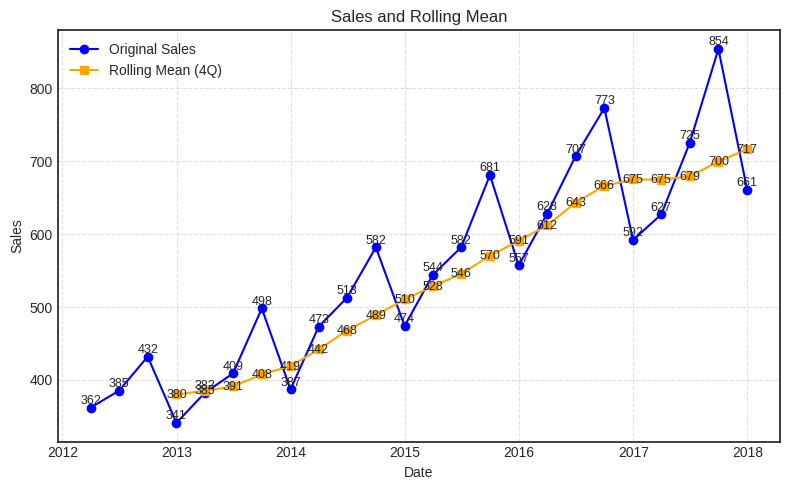

In [23]:
# Visualize Rolling mean
# YOUR CODE HERE
df['Rolling_Mean'] = df['Sales'].rolling(window=4).mean()
plt.figure(figsize=(8, 5))
plt.plot(df.index, df['Sales'], marker='o', label='Original Sales', color='blue')
plt.plot(df.index, df['Rolling_Mean'], marker='s', label='Rolling Mean (4Q)', color='orange')

for x, y in zip(df.index, df['Sales']):                         #data labels for original sales
    plt.text(x, y + 5, f'{y:.0f}', ha='center', fontsize=9)

for x, y in zip(df.index, df['Rolling_Mean']):                  #data labels for rolling mean
    if pd.notna(y):
        plt.text(x, y - 5, f'{y:.0f}', ha='center', fontsize=9)

plt.title('Sales and Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Visualize if the variance is constant

Hint: [Rolling standard deviation](https://pandas.pydata.org/docs/reference/api/pandas.core.window.rolling.Rolling.std.html)

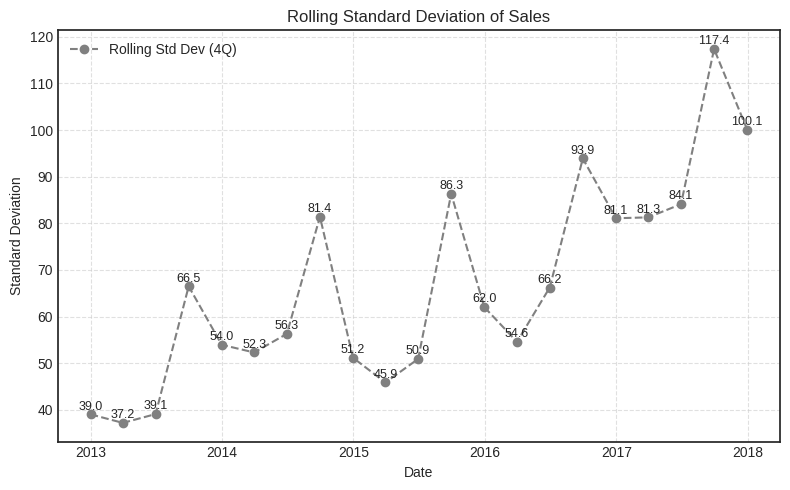

In [28]:
# Rolling standard deviation
# YOUR CODE HERE
df['Rolling_STD'] = df['Sales'].rolling(window=4).std()

plt.figure(figsize=(8, 5))
plt.plot(df.index, df['Rolling_STD'], color='grey', marker='o', linestyle='--', label='Rolling Std Dev (4Q)')

for x, y in zip(df.index, df['Rolling_STD']):           # Add data labels
    if pd.notna(y):
        plt.text(x, y + 1, f'{y:.1f}', ha='center', fontsize=9)

plt.title('Rolling Standard Deviation of Sales')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Based on the observations report whether the series is stationary or not.

#### Visualize the patterns in time series - trend, seasonality, residuals (1 point)

Hint: See Module 5 - AST2 EDA > Patterns in a time series

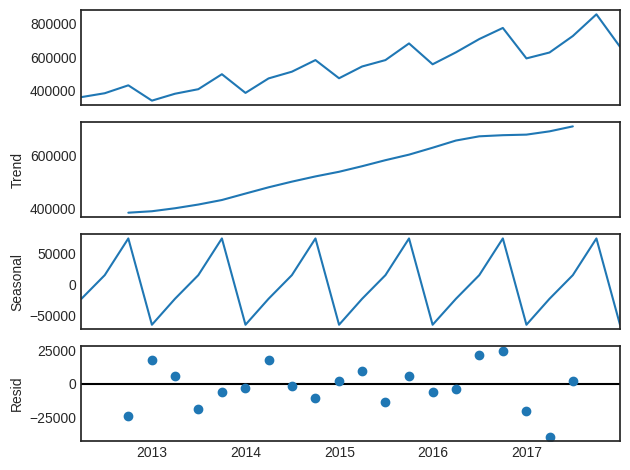

In [30]:
# Applying seasonal decompose
# YOUR CODE HERE
df = pd.read_csv('ts_frenchretail.csv', index_col='Date', parse_dates=True)
result = seasonal_decompose(df, model='additive')

# Plotting trend, seasonality
# YOUR CODE HERE
result.plot()
plt.show()

Report if there are any observable patterns in terms of trend, seasonality , or cyclic behavior.

### **Detrending**

####  Detrend the time series (0.5 point)

Detrending a time series is to remove the trend component from a time series.

Hint:
- Subtract the line of best fit `scipy.signal.detrend()`

Text(0.5, 1.0, 'Sales detrended by subtracting the least squares fit')

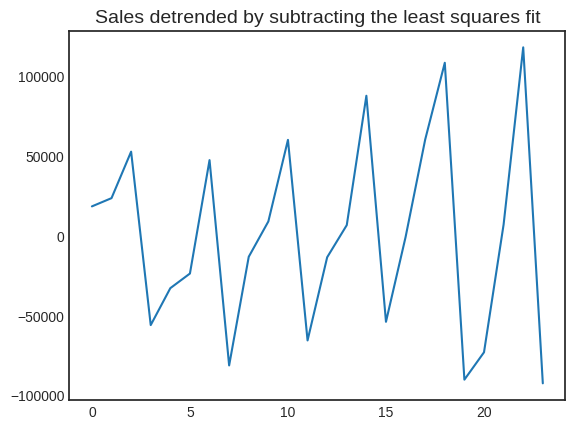

In [36]:
# YOUR CODE HERE
detrended = scipy.signal.detrend(df.Sales.values)
plt.plot(detrended)
plt.title('Sales detrended by subtracting the least squares fit', fontsize=14)

Text(0.5, 1.0, 'Sales detrended by subtracting the trend component')

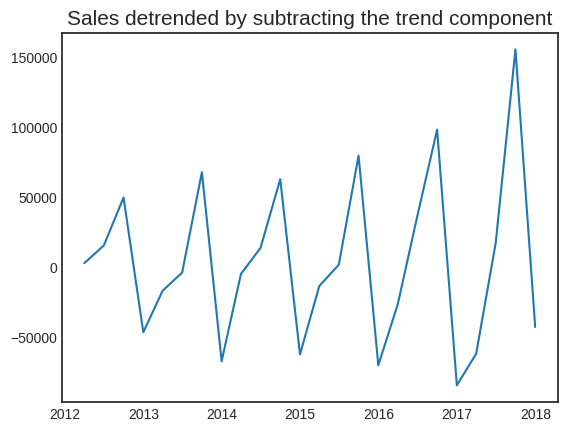

In [37]:
# Decomposing time-series first
result_mul = seasonal_decompose(df['Sales'], model='multiplicative', extrapolate_trend='freq')
# Detrending the time-series by trend component
detrended = df.Sales.values - result_mul.trend

# Plotting the detrended time series
plt.plot(detrended)
plt.title('Sales detrended by subtracting the trend component', fontsize=15)

[]

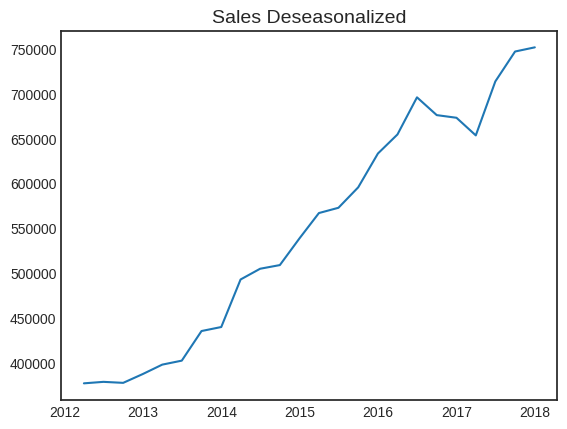

In [39]:
# Time Series Decomposition
result_mul = seasonal_decompose(df['Sales'], model='multiplicative', extrapolate_trend='freq')

# Deseasonalize the time series
deseasonalized = df.Sales.values / result_mul.seasonal
plt.plot(deseasonalized)
plt.title('Sales Deseasonalized', fontsize=14)
plt.plot()

### **Lag Plots** (Optional)

#### Visualize the Lag plots

A Lag plot is a scatter plot of a time series against a lag of itself. It is normally used to check for autocorrelation. If there is any pattern existing in the series, the series is autocorrelated. If there is no such pattern, the series is likely to be random white noise.

For reference, see Module 5 - AST2 > Lag Plots

Hint: `pandas.plotting.lag_plot()`

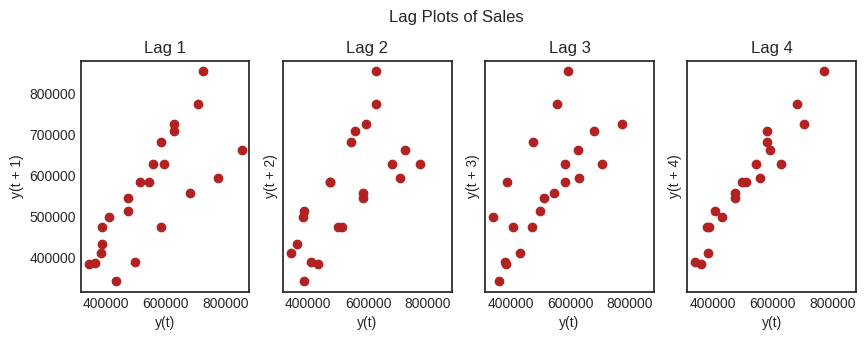

In [42]:
# Visualize lag plots
# YOUR CODE HERE
fig, axes = plt.subplots(1, 4, figsize=(10,3), sharex=True, sharey=True, dpi=100)
for i, ax in enumerate(axes.flatten()[:4]):
    lag_plot(df.Sales, lag=i+1, ax=ax, c='firebrick')
    ax.set_title('Lag ' + str(i+1))

fig.suptitle('Lag Plots of Sales', y=1.05)
plt.show()

### Report Analysis

- Give the summary about this time series